In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from helpers.simulation import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [ ]:
path = str(INFERENCE_DATASETS / 'glitch_datasets' /'real_glitch_hm_dataset.h5')
with h5py.File(path, 'r') as h5:
    real_images = h5['QT'][:]
real_images = torch.tensor(real_images, dtype=torch.float32)
real_images = real_images.permute(0, 3, 1, 2)

path = str(INFERENCE_DATASETS / 'glitch_datasets' / 'ordinary_glitch_hm_dataset.h5')
with h5py.File(path, 'r') as h5:
    ordinary_images = h5['QT'][:]
    ordinary_betas = h5['beta'][:]
    ordinary_levels = np.abs(h5['level'][:])
ordinary_images = torch.tensor(ordinary_images, dtype=torch.float32)
ordinary_images = ordinary_images.permute(0, 3, 1, 2)

with h5py.File(glitch_hm_dataset_path, 'r') as h5:
    training_glitches = h5['QT'][:]
    training_betas = h5['beta'][:]
    training_levels = h5['level'][:]

with h5py.File(gw_hm_dataset_path, 'r') as h5:
    training_gws = h5['QT'][:]

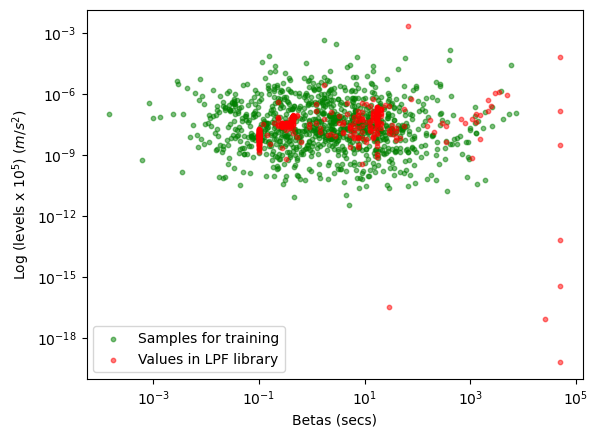

In [3]:
plt.scatter(training_betas, training_levels, s=10, color='green', alpha=0.5, label='Samples for training')
plt.scatter(ordinary_betas, ordinary_levels, s=10, color='red', alpha=0.5, label='Values in LPF library')
plt.xlabel('Betas (secs)')
plt.ylabel('Log (levels x $10^5$) ($m/s^2$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [10]:
model = CNN(width=8, bn=True, normalise=False)
device = torch.device("mps")
#weights_path = TRAINING_RESULTS/'ext_high_mass'/'run_280226_210221'/'best_model_weights.pth'
weights_path = TRAINING_RESULTS/'high_mass'/ 'good_runs' /'run_090326_160539'/'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Real glitches

In [6]:
with torch.no_grad():
    outputs = model(real_images.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

target = torch.tensor([0, 1], device=preds.device)

correct = (preds == target).all(dim=1).sum().item()
glitch_only = (preds[:, 1] == 1).sum().item()
total = real_images.shape[0]
print('Accuracy on real LPF glitches:', round(correct/total, 3))
print('Glitch only accuracy:', round(glitch_only/total, 3))

Accuracy on real LPF glitches: 0.44
Glitch only accuracy: 0.982


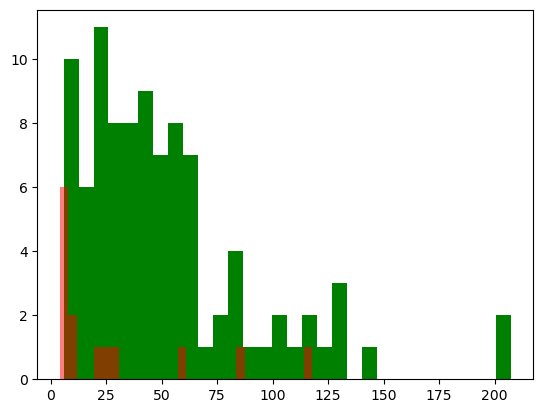

In [5]:
wrong = torch.where((preds != target).any(dim=1))[0].detach().cpu().numpy()
right = torch.where((preds == target).all(dim=1))[0].detach().cpu().numpy()

snrs_right = real_images[right].amax(dim=(2,3)).detach().cpu().numpy()
snrs_wrong = real_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()

plt.hist(snrs_right[:, 0], bins=30, color='green')
plt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5)
plt.show()

The prediction is: tensor([[0.8607, 1.0000]], device='mps:0')


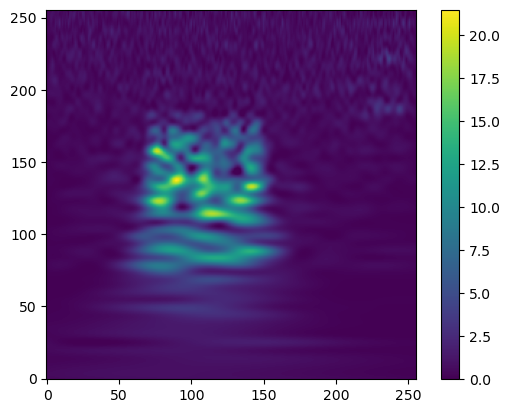

In [34]:
index = 20
image = real_images[index].unsqueeze(0)
with torch.no_grad():
    pred = torch.sigmoid(model(image.to(device)))
print('The prediction is:', pred)

image = real_images[index].detach().cpu().numpy()
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()

## Ordinary params

In [7]:
with torch.no_grad():
    outputs = model(ordinary_images.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

target = torch.tensor([0, 1], device=preds.device)

correct = (preds == target).all(dim=1).sum().item()
glitch_only = (preds[:, 1] == 1).sum().item()
total = ordinary_images.shape[0]
print('Accuracy on glitches with ordinary params:', round(correct/total, 3))
print('Glitch only accuracy:', round(glitch_only/total, 3))

Accuracy on glitches with ordinary params: 0.907
Glitch only accuracy: 0.995


In [8]:
wrong = torch.where((preds != target).any(dim=1))[0].detach().cpu().numpy()
right = torch.where((preds == target).all(dim=1))[0].detach().cpu().numpy()

"""snrs_right = ordinary_images[right].amax(dim=(2,3)).detach().cpu().numpy()
snrs_wrong = ordinary_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()

plt.hist(snrs_right[:, 0], bins=30, color='green', label='correct')
plt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5, label='wrong')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.legend()
plt.show()"""

"snrs_right = ordinary_images[right].amax(dim=(2,3)).detach().cpu().numpy()\nsnrs_wrong = ordinary_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()\n\nplt.hist(snrs_right[:, 0], bins=30, color='green', label='correct')\nplt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5, label='wrong')\nplt.xlabel('SNR')\nplt.ylabel('Count')\nplt.legend()\nplt.show()"

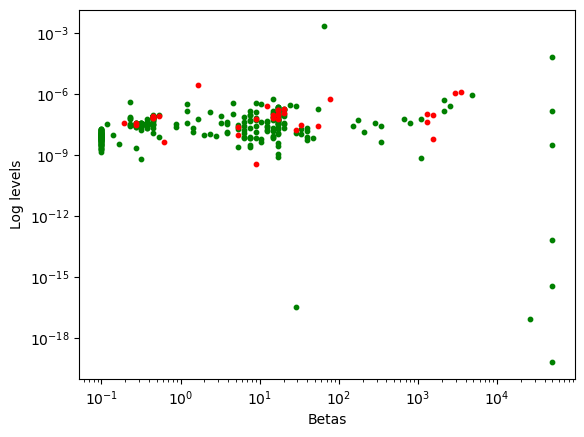

In [10]:
right_betas = ordinary_betas[right]
right_levels = ordinary_levels[right]

wrong_betas = ordinary_betas[wrong]
wrong_levels = ordinary_levels[wrong]

plt.scatter(right_betas, right_levels, s=10, color='green')
plt.scatter(wrong_betas, wrong_levels, s=10, color='red')
#plt.scatter(training_betas, training_levels, s=10, color='blue')
plt.xlabel('Betas')
plt.ylabel('Log levels')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [9]:
"""snrs_train = np.max(training_glitches, axis=(1,2))

plt.hist(snrs_train[:, 0], bins=30, color='blue')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.show()"""

"snrs_train = np.max(training_glitches, axis=(1,2))\n\nplt.hist(snrs_train[:, 0], bins=30, color='blue')\nplt.xlabel('SNR')\nplt.ylabel('Count')\nplt.show()"

The prediction is: tensor([[8.4884e-06, 9.9754e-01]], device='mps:0')


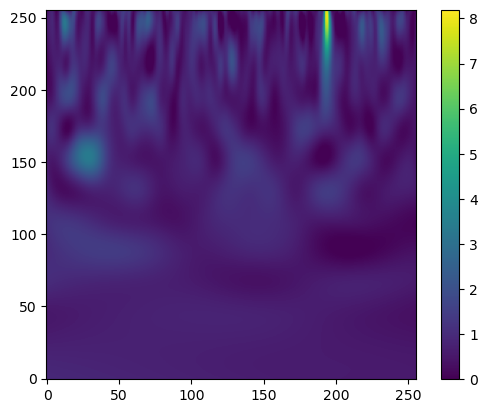

In [13]:
index = 273
image = ordinary_images[index].unsqueeze(0)
with torch.no_grad():
    pred = torch.sigmoid(model(image.to(device)))
print('The prediction is:', pred)

image = ordinary_images[index].detach().cpu().numpy()
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()

## SNRs

In [97]:
with h5py.File(glitch_hm_dataset_path, 'r') as h5:
    glitches = h5['QT'][:]
    glitch_level = h5['level'][:]
    glitch_beta = h5['beta'][:]
    glitch_injpoint = h5['inj_point'][:]
glitches = torch.tensor(glitches, dtype=torch.float32)
glitches = glitches.permute(0, 3, 1, 2)

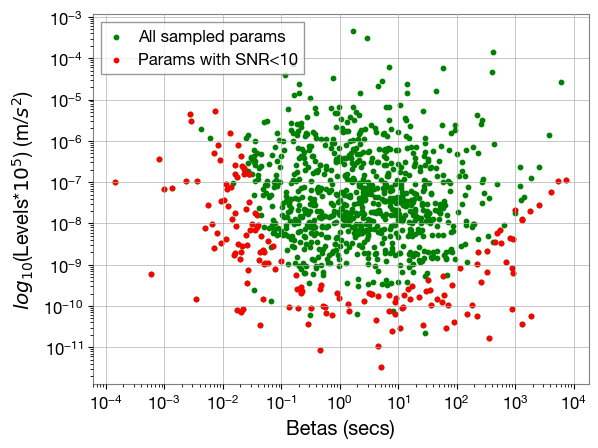

0.163


In [105]:
snrs_glitches = glitches.amax(dim=(1,2,3)).detach().cpu().numpy()
small_betas = glitch_beta[np.where(snrs_glitches < 10)]
small_levels = glitch_level[np.where(snrs_glitches < 10)]

plt.scatter(glitch_beta, glitch_level, s=10, color='green', label='All sampled params')
plt.scatter(small_betas, small_levels, s=10, color='red', label='Params with SNR<10')
plt.xlabel('Betas (secs)')
plt.ylabel('$log_{10}$(Levels*$10^5$) (m/$s^2$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()
print(len(small_betas)/len(snrs_glitches))

[ 0  1  7 14 15 19 23 32]


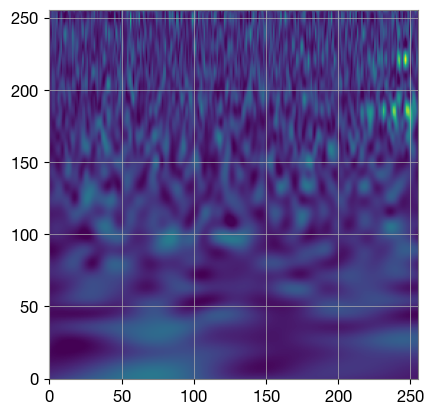

In [110]:
print(np.where(snrs_glitches < 10)[0][0:8])

image = glitches[0]
plt.imshow(image[0], origin='lower')
plt.show()

## Confusion matrix

In [11]:
dataset = LISADataset(training_hm_dataset_path)

N = len(dataset)
train_size = int(0.7 * N)
val_size   = int(0.2 * N)
test_size  = N - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator)

In [16]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

In [17]:
cm_gw = confusion_matrix(labels[:,0], preds[:,0])
cm_glitch = confusion_matrix(labels[:,1], preds[:,1])

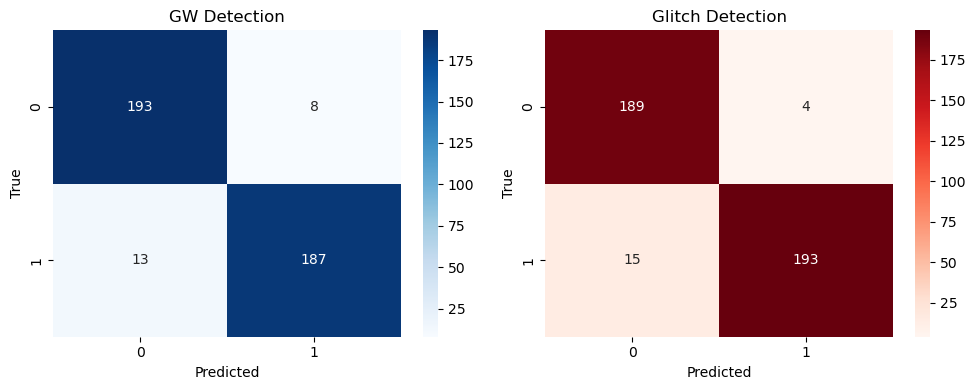

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_gw, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("GW Detection")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_glitch, annot=True, fmt="d", cmap="Reds", ax=axes[1])
axes[1].set_title("Glitch Detection")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

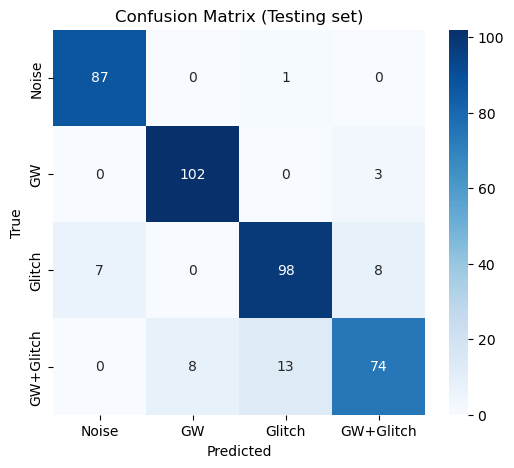

In [20]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

## Time sliding

In [6]:
from helpers.qtransform import *

MASS_CATEGORY = 'high_mass'  # 'low_mass', 'high_mass', 'ext_high_mass'
SPEC = SPECS[MASS_CATEGORY]

RESOLUTION = 256
REPRESENTATION = 'qscan'  # 'qscan' or 'varqscan'

def run_one_sample(args):
    tcen, X, Y, Z = args
    tdi_dict = make_tdi_dict(X, Y, Z)
    
    event = {'t_inj': PIPE['t_inj'] - tcen}

    QT = np.zeros((RESOLUTION, RESOLUTION, 3))
    for channel in ['A', 'E', 'T']:
        if REPRESENTATION == 'varqscan':
            t_arr, f_arr, data = varq_transform(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                                        frange=SPEC['frange'], trange=SPEC['trange'], Qvals=SPEC['Qvals'])
        elif REPRESENTATION == 'qscan':
            t_arr, f_arr, data = generate_qscan(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                             frange=SPEC['frange'], trange=SPEC['trange'], Q=SPEC['Q'])

        QT[:, :, ['A', 'E', 'T'].index(channel)] = data

    return QT, t_arr, f_arr

In [77]:
with h5py.File(glitch_hm_dataset_path, 'r') as h5:
    glitches = h5['QT'][:]
    glitchX = h5['X'][:]
    glitchY = h5['Y'][:]
    glitchZ = h5['Z'][:]
    #glitch_level = h5['level'][:]
    #glitch_beta = h5['beta'][:]
    #glitch_injpoint = h5['inj_point'][:]
    glitch_tcen = h5['tcen'][:]
    glitch_tarr = h5['t_qscan'][:]
    glitch_farr = h5['f_qscan'][:]
glitches = torch.tensor(glitches, dtype=torch.float32)
glitches = glitches.permute(0, 3, 1, 2)

In [83]:
model.eval()
with torch.no_grad():
    outputs = model(glitches.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

correct = torch.where((preds == torch.tensor([0,1], device=preds.device)).all(dim=1))[0]
print(len(correct)/len(glitches))
print(correct[0:7])

0.825
tensor([0, 2, 3, 4, 5, 6, 7], device='mps:0')


tensor([[0.0203, 1.0000]], device='mps:0')


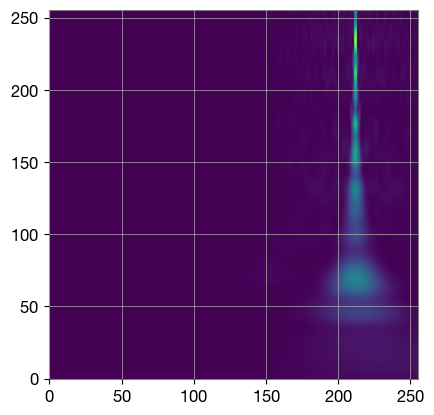

In [95]:
index = 6
image = glitches[index]

with torch.no_grad():
    out = torch.sigmoid(model(image.unsqueeze(0).to(device)))

true_gw_pred = out[0][0].detach().cpu().numpy()
true_glitch_pred = out[0][1].detach().cpu().numpy()
print(out)
plt.imshow(image[0], origin='lower')

In [79]:
tcen_arr = np.linspace(-3, 3, 50)*3600

X = glitchX[index]
Y = glitchY[index]
Z = glitchZ[index]
tcen_act = glitch_tcen[index]

image_arr = np.zeros((len(tcen_arr), 256, 256, 3))
for i, tcen in enumerate(tcen_arr):
    args = (tcen, X, Y, Z)
    QT, tarr, farr = run_one_sample(args)
    image_arr[i, :, :, :] = QT

image_arr = torch.tensor(image_arr, dtype=torch.float32)
image_arr = image_arr.permute(0, 3, 1, 2)

In [92]:
with torch.no_grad():
    outputs = model(image_arr.to(device).contiguous())
    probs = torch.sigmoid(outputs)

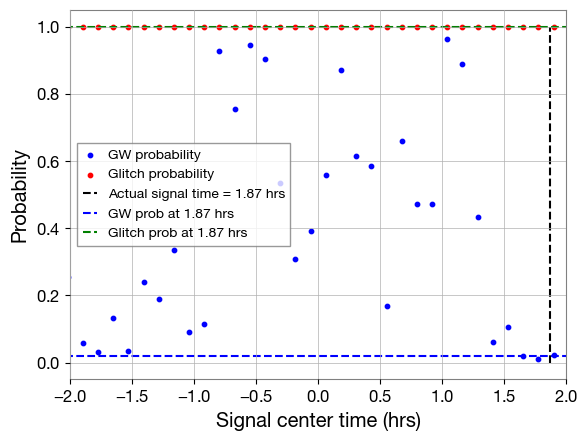

In [96]:
gw_prob = probs[:, 0].detach().cpu().numpy()
glitch_prob = probs[:, 1].detach().cpu().numpy()
tcen_act = 1.87*3600
plt.scatter(tcen_arr/3600, gw_prob, color='blue', label='GW probability', s=10)
plt.scatter(tcen_arr/3600, glitch_prob, color='red', label='Glitch probability', s=10)
plt.vlines(x=tcen_act/3600, ymin=0, ymax=1, color='black', linestyle='dashed',
 label=f'Actual signal time = {round(tcen_act/3600, 2)} hrs')
plt.hlines(y=[true_gw_pred], xmin=-3, xmax=3, color='blue', linestyle='dashed', label=f'GW prob at {round(tcen_act/3600, 2)} hrs')
plt.hlines(y=[true_glitch_pred], xmin=-3, xmax=3, color='green', linestyle='dashed', label=f'Glitch prob at {round(tcen_act/3600, 2)} hrs')
plt.xlabel('Signal center time (hrs)')
plt.ylabel('Probability')
plt.legend(fontsize=10)
plt.xlim(-2,2)
#plt.ylim(-0.5, 1.2)
plt.show()